# Deplying an AI Model on a Simulated Edge Device: MNIST Datasest

### Import necessary libraries, load dataset, normalize data & show sample images

In [48]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

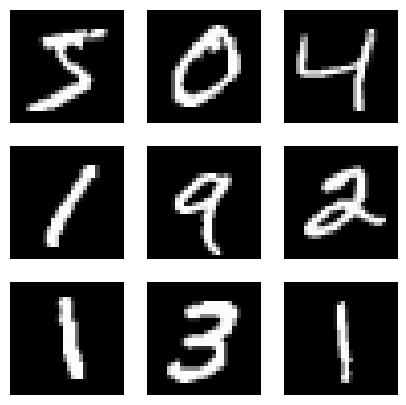

In [61]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
plt.figure(figsize=(5,5))
                   
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis('off')
plt.show()

#### Define & Train Neural Network

In [64]:
# Define model architecture 
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    # Input layer (flatten 28x28 pixels) 
    tf.keras.layers.Dense(128, activation='relu'),
    # Hidden layer
    tf.keras.layers.Dense(10, activation='softmax') 
    # Output layer (10 classes) 
])

# Compile model 
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Train model
model.fit(x_train, 
          y_train, 
          epochs=5, 
          validation_data=(x_test, y_test)) 

# Save trained model 
model.save("mnist_model.keras")
print("Model training complete and saved as mnist_model.keras")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8789 - loss: 0.4269 - val_accuracy: 0.9601 - val_loss: 0.1373
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9640 - loss: 0.1211 - val_accuracy: 0.9692 - val_loss: 0.1006
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9763 - loss: 0.0798 - val_accuracy: 0.9744 - val_loss: 0.0844
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9837 - loss: 0.0557 - val_accuracy: 0.9769 - val_loss: 0.0786
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9877 - loss: 0.0415 - val_accuracy: 0.9771 - val_loss: 0.0700
Model training complete and saved as mnist_model.keras


#### Convert the MOdel to TensorFlow Lite Format

In [66]:
# Load trained model
model = tf.keras.models.load_model("mnist_model.keras")

# convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Ssave the converted model
with open("mnist_model_tflite",
          "wb") as f:
    f.write(tflite_model)
    print("model successfully converted and saved as mnist_model_tflite")

INFO:tensorflow:Assets written to: C:\Users\presc\AppData\Local\Temp\tmp3z4tyqd4\assets


INFO:tensorflow:Assets written to: C:\Users\presc\AppData\Local\Temp\tmp3z4tyqd4\assets


Saved artifact at 'C:\Users\presc\AppData\Local\Temp\tmp3z4tyqd4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1924210443664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1924210444048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925859807824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1925859812624: TensorSpec(shape=(), dtype=tf.resource, name=None)
model successfully converted and saved as mnist_model_tflite


#### Load & Run Inference with TensorFlow Lite

In [68]:
# Load TensorFlow Lite model
interpreter = tf.lite.Interpreter(
    model_path="mnist_model_tflite") 
interpreter.allocate_tensors() 

# Get input and output tensor details 
input_details = interpreter.get_input_details() 
output_details = interpreter.get_output_details() 
print("Input Details:", 
      input_details) 

print("Output Details:", 
      output_details)

Input Details: [{'name': 'serving_default_input_layer_2:0', 'index': 0, 'shape': array([ 1, 28, 28]), 'shape_signature': array([-1, 28, 28]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([ 1, 10]), 'shape_signature': array([-1, 10]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


C:\Users\presc\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


#### Perform Inference with TensorFlow Lite

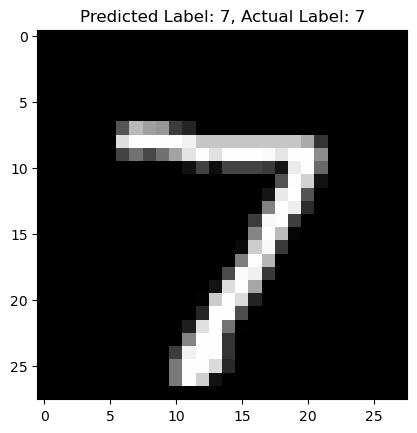

In [70]:
# Select a test image 
test_image = x_test[0].astype(np.float32) 

# Ensure data type matches model input 
test_image = np.expand_dims(test_image, axis=0) 

# Reshape for model input 
# Set the input tensor 
interpreter.set_tensor(input_details[0]['index'], test_image) 

# Run inference 
interpreter.invoke() 

# Get the prediction 
output_data = interpreter.get_tensor(output_details[0]['index']) 
predicted_label = np.argmax(output_data) 

# Display the image and prediction 
plt.imshow(x_test[0], cmap="gray") 
plt.title(f"Predicted Label: {predicted_label}, Actual Label: {y_test[0]}") 
plt.show()